In [2]:
import os
import numpy as np 
import pandas as pd
#import cudf # to leverage GPU acceleration
import time  # To measure execution time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [4]:
df_path = "../Outputs/final_structured_dataset.csv"
df = pd.read_csv(df_path)
print(df.shape)
df.head(2)

(2307, 39)


,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,0,68,1,71.392857,123.730769,75.320000,88.747692,...,7.34,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,0,45,1,106.461538,111.900000,73.545455,85.210606,...,7.19,1,0,0,0,0,3.000,1,0,0


In [5]:
has_radio_disch_path = "../Outputs/has_radio_disch_notes.csv"
df_has_radio_disch = pd.read_csv(has_radio_disch_path)
print(df_has_radio_disch.shape)
df_has_radio_disch.head(2)

(2307, 17)


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status,has_discharge_note,has_radiology_note
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1,1,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1,0,0


In [6]:
textual_data_path = "../Outputs/textual_data_preprocessed.csv"
df_textual_data = pd.read_csv(textual_data_path)
print(df_textual_data.shape)
df_textual_data.head(2)

(2307, 563)


,hadm_id,disch_tfidf_svd_0,disch_tfidf_svd_1,disch_tfidf_svd_2,disch_tfidf_svd_3,disch_tfidf_svd_4,disch_tfidf_svd_5,disch_tfidf_svd_6,disch_tfidf_svd_7,disch_tfidf_svd_8,...,radiology_bert_pca_105,radiology_bert_pca_106,radiology_bert_pca_107,radiology_bert_pca_108,radiology_bert_pca_109,radiology_bert_pca_110,radiology_bert_pca_111,radiology_bert_pca_112,radiology_bert_pca_113,radiology_bert_pca_114
0,26184834,0.820109,0.029019,0.043053,0.292052,-0.009378,-0.00728,0.082465,-0.090557,-0.088351,...,-0.022508,-0.009156,0.061839,0.085673,0.005974,-0.00588,0.00145,-0.002955,-0.07325,0.022813
1,22096005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Step 1: Check if `hadm_id` is unique in all datasets
print("df['hadm_id'].is_unique:", df['hadm_id'].is_unique)
print("df_has_radio_disch['hadm_id'].is_unique:", df_has_radio_disch['hadm_id'].is_unique)
print("df_textual_data['hadm_id'].is_unique:", df_textual_data['hadm_id'].is_unique)

# Step 2: Convert to sets
ids_df = set(df['hadm_id'])
ids_radio = set(df_has_radio_disch['hadm_id'])
ids_text = set(df_textual_data['hadm_id'])

# Step 3: Check equality
all_match = (ids_df == ids_radio == ids_text)
print("All datasets have the same hadm_id values?", all_match)

# Step 4 (optional): See where mismatches occur if any
missing_in_radio = ids_df - ids_radio
missing_in_text = ids_df - ids_text

print("hadm_ids in df but not in df_has_radio_disch:", missing_in_radio)
print("hadm_ids in df but not in df_textual_data:", missing_in_text)

df['hadm_id'].is_unique: True
df_has_radio_disch['hadm_id'].is_unique: True
df_textual_data['hadm_id'].is_unique: True
All datasets have the same hadm_id values? True
hadm_ids in df but not in df_has_radio_disch: set()
hadm_ids in df but not in df_textual_data: set()


##### Use df as the benchmark/base dataset.
* From df_has_radio_disch, take only:
  * "hadm_id", "has_discharge_note", and "has_radiology_note".
* From df_textual_data, take all columns, but first:
  * Fill NaN values with 0.
* Merge both into df, keeping all df columns and aligning by hadm_id.

In [8]:
# Filter df_has_radio_disch to keep only necessary columns
df_radio_disch_filtered = df_has_radio_disch[['hadm_id', 'has_discharge_note', 'has_radiology_note']]

# Fill NaNs in df_textual_data with 0
df_textual_data_filled = df_textual_data.fillna(0)

# Merge into df (overwriting df)
df = df.merge(df_radio_disch_filtered, on='hadm_id') \
       .merge(df_textual_data_filled, on='hadm_id')

# Check the result
print("Final df shape after merging:", df.shape)
df.head()

Final df shape after merging: (2307, 603)


,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,radiology_bert_pca_105,radiology_bert_pca_106,radiology_bert_pca_107,radiology_bert_pca_108,radiology_bert_pca_109,radiology_bert_pca_110,radiology_bert_pca_111,radiology_bert_pca_112,radiology_bert_pca_113,radiology_bert_pca_114
0,10001884,26184834,37510196,0,68,1,71.392857,123.730769,75.320000,88.747692,...,-0.022508,-0.009156,0.061839,0.085673,0.005974,-0.005880,0.001450,-0.002955,-0.073250,0.022813
1,10009823,22096005,31805686,0,45,1,106.461538,111.900000,73.545455,85.210606,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,10010471,29842315,32119961,0,89,1,86.920000,104.840000,54.280000,68.506667,...,0.003392,-0.007596,0.030635,-0.107823,-0.006033,-0.076772,0.059937,-0.060827,0.069548,0.120467
3,10013569,27993048,38857852,0,54,0,80.285714,108.640000,59.080000,72.800000,...,-0.003196,-0.050115,-0.040426,0.056137,0.045888,-0.168760,0.025004,0.035763,0.061470,-0.005542
4,10021454,29492087,33300154,1,88,1,57.920000,110.854130,48.005116,68.954787,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Handling NaNs in Textual Features

NaNs in BERT or TF-IDF-based features reflect **true absence of text** (e.g., no discharge or radiology note), not random missingness.

**Recommended Strategy**: Impute with zeros (i.e., zero vectors), because:

- Embeddings (TF-IDF/SVD, BERT/PCA) are typically centered around 0
- Zero intuitively represents "no information"
- Avoids misleading similarity introduced by mean/KNN imputation

**Model-Aware Missingness**:  
We also include binary flags (`has_discharge_note`, `has_radiology_note`) to indicate whether a note exists. This helps the model:

- Distinguish zero-imputed rows from real embeddings  
- Learn patterns associated with note absence  
- Preserve interpretability and semantic structure

### Step 1: Data Prep

In [29]:
# 🧹 Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 📦 Assume your imputed dataframe is called df
# Drop identifiers or unrelated columns
exclude_cols = ['subject_id', 'hadm_id', 'stay_id']
features = [col for col in df.columns if col not in exclude_cols + ['survival_status']]

# 📤 Define X and y
X = df[features]
y = df['survival_status']

# 🧪 Split into training and validation sets (70% / 30%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# ⚖️ Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Step 2: LASSO for Feature Selection

#### 2.1 LASSO with Cross-Validation (Binomial Deviance)

In [30]:
from sklearn.linear_model import LogisticRegressionCV

# 🔗 Run LASSO using LogisticRegressionCV with binomial deviance scoring
lasso = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 100),  # Wider, smoother λ range
    penalty='l1',
    solver='saga',
    cv=10,
    scoring='neg_log_loss',  # binomial deviance
    random_state=42,
    max_iter=5000,
    n_jobs=-1,
    refit=False
)
lasso.fit(X_train_scaled, y_train)

LogisticRegressionCV(Cs=array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226722e-03, 1.23284674e-03, 1.41747416e-03,
       1.62975083e-03, 1.87...
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02]),
                     cv=10, max_iter=5000, n_jobs=-1, penalty='l1',
                     random_state=42, refit=False, scoring='neg_log_loss',
                     solver='saga')

#### 2.2 Identify Min λ and 1-SE λ + Plot (Fig 2A)

✅ Min λ: 8.11131
✅ 1-SE λ: 24.77076


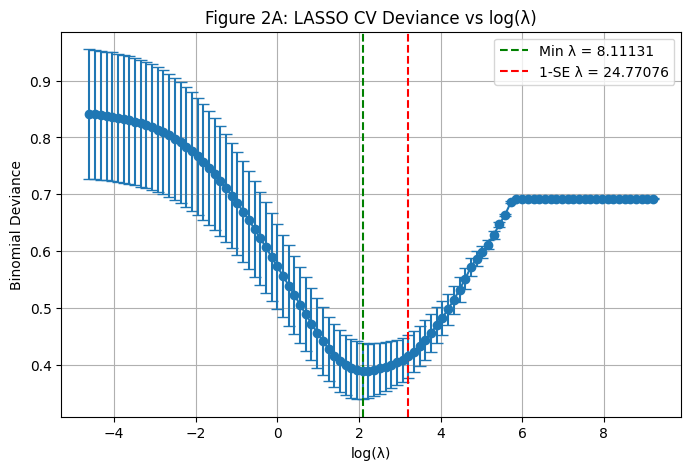

In [31]:
# Convert to positive deviance
scores = -lasso.scores_[1]  # Use class label 1
mean_scores = np.mean(scores, axis=0)
std_scores = np.std(scores, axis=0)

# Map to λ
Cs = lasso.Cs_
lambdas = 1 / Cs  # λ = 1 / C

# Sort lambdas and align scores
sorted_indices = np.argsort(lambdas)
sorted_lambdas = lambdas[sorted_indices]
sorted_mean_scores = mean_scores[sorted_indices]
sorted_std_scores = std_scores[sorted_indices]

# Identify λ_min and λ_1se
min_idx = np.argmin(sorted_mean_scores)
min_lambda = sorted_lambdas[min_idx]
min_dev = sorted_mean_scores[min_idx]
se = sorted_std_scores[min_idx]

# 1-SE Rule: largest λ within 1 std of min dev
eligible = np.where((sorted_mean_scores <= min_dev + se) & (sorted_lambdas > min_lambda))[0]
lambda_1se = sorted_lambdas[eligible[int(len(eligible) * 0.75)]] if len(eligible) > 0 else min_lambda


# ✅ Show values
print(f"✅ Min λ: {min_lambda:.5f}")
print(f"✅ 1-SE λ: {lambda_1se:.5f}")

# 📊 Plot Figure 2A
log_sorted_lambdas = np.log(sorted_lambdas)

plt.figure(figsize=(8, 5))
plt.errorbar(log_sorted_lambdas, sorted_mean_scores, yerr=sorted_std_scores, fmt='-o', capsize=4)
plt.axvline(np.log(min_lambda), color='green', linestyle='--', label=f'Min λ = {min_lambda:.5f}')
plt.axvline(np.log(lambda_1se), color='red', linestyle='--', label=f'1-SE λ = {lambda_1se:.5f}')
plt.xlabel('log(λ)')
plt.ylabel('Binomial Deviance')
plt.title('Figure 2A: LASSO CV Deviance vs log(λ)')
plt.legend()
plt.grid(True)
plt.show()

#### 2.3 Coefficient Profile Plot

In [33]:
# from sklearn.linear_model import LogisticRegression

# lambda_vals = np.logspace(-4, 2, 100)
# coefs = []

# for C_val in 1 / lambda_vals:
#     model = LogisticRegression(
#         penalty='l1',
#         solver='saga',
#         C=C_val,
#         max_iter=5000,
#         fit_intercept=True,
#         random_state=42
#     )
#     model.fit(X_train_scaled, y_train)
#     coefs.append(model.coef_[0])

# coefs = np.array(coefs)

# # 📈 Plot Figure 2B
# plt.figure(figsize=(10, 6))
# for i, feature in enumerate(X_train.columns):
#     plt.plot(np.log(lambda_vals), coefs[:, i], label=feature)

# plt.xlabel('log(λ)')
# plt.ylabel('Coefficient value')
# plt.title('Coefficient Profile Plot')
# plt.axvline(np.log(lambda_1se), color='red', linestyle='--', label='Selected λ (1-SE)')
# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05), fontsize='small', ncol=1)
# plt.grid(True)
# plt.show()

#### 2.4 Fit Final LASSO Model at selected λ and Extract Features

In [36]:
# Fit final model at selected λ
C_1se = 1 / lambda_1se
final_lasso = LogisticRegression(
    C=C_1se,
    penalty='l1',
    solver='saga',
    max_iter=5000,
    random_state=42
)
final_lasso.fit(X_train_scaled, y_train)

# Extract non-zero coefficients
import pandas as pd

lasso_coef = pd.Series(final_lasso.coef_[0], index=X_train.columns)
lasso_selected = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)

# Display summary
print(f"✅ LASSO selected {len(lasso_selected)} features at λ = {lambda_1se:.5f}")
display(lasso_selected.to_frame(name="Coefficient"))

✅ LASSO selected 64 features at λ = 24.77076


,Coefficient
disch_tfidf_svd_1,-1.110360
disch_tfidf_svd_5,-0.461847
disch_tfidf_svd_3,-0.458268
disch_tfidf_svd_13,0.380333
disch_tfidf_svd_21,-0.314935
...,...
radiology_bert_pca_41,0.006016
disch_tfidf_svd_11,-0.004072
radiology_bert_pca_44,-0.003775
radio_tfidf_svd_119,-0.001243


In [39]:
print(lasso_selected.to_frame(name="Coefficient").to_string())

                        Coefficient
disch_tfidf_svd_1         -1.110360
disch_tfidf_svd_5         -0.461847
disch_tfidf_svd_3         -0.458268
disch_tfidf_svd_13         0.380333
disch_tfidf_svd_21        -0.314935
Lactate                    0.298088
disch_tfidf_svd_7         -0.253951
HR                         0.235310
disch_tfidf_svd_18        -0.222936
BUN                        0.185157
BT                        -0.163424
PT                         0.146652
anchor_age                 0.135325
disch_tfidf_svd_27        -0.133015
disch_tfidf_svd_61        -0.132752
disch_tfidf_svd_0         -0.131873
disch_tfidf_svd_23         0.128414
disch_tfidf_svd_8         -0.121516
disch_tfidf_svd_4         -0.115063
disch_tfidf_svd_49         0.103340
discharge_bert_pca_5      -0.085179
disch_tfidf_svd_6         -0.084117
disch_tfidf_svd_16        -0.083320
Hemoglobin                -0.076588
disch_tfidf_svd_14        -0.067570
radiology_bert_pca_5       0.053109
disch_tfidf_svd_71        -0

### 🌲 Step 3: XGBoost for Feature Importance

/home/nmamatov/.local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:33:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Top 64 XGBoost features (by relative importance %):
disch_tfidf_svd_1        100.000000
Lactate                   57.081249
PT                        53.630726
disch_tfidf_svd_0         50.090885
pH                        45.279842
                            ...    
Glucose                   23.510292
radiology_bert_pca_41     23.484833
radiology_bert_pca_1      23.401596
radiology_bert_pca_0      23.272316
radio_tfidf_svd_13        23.160362
Length: 64, dtype: float32


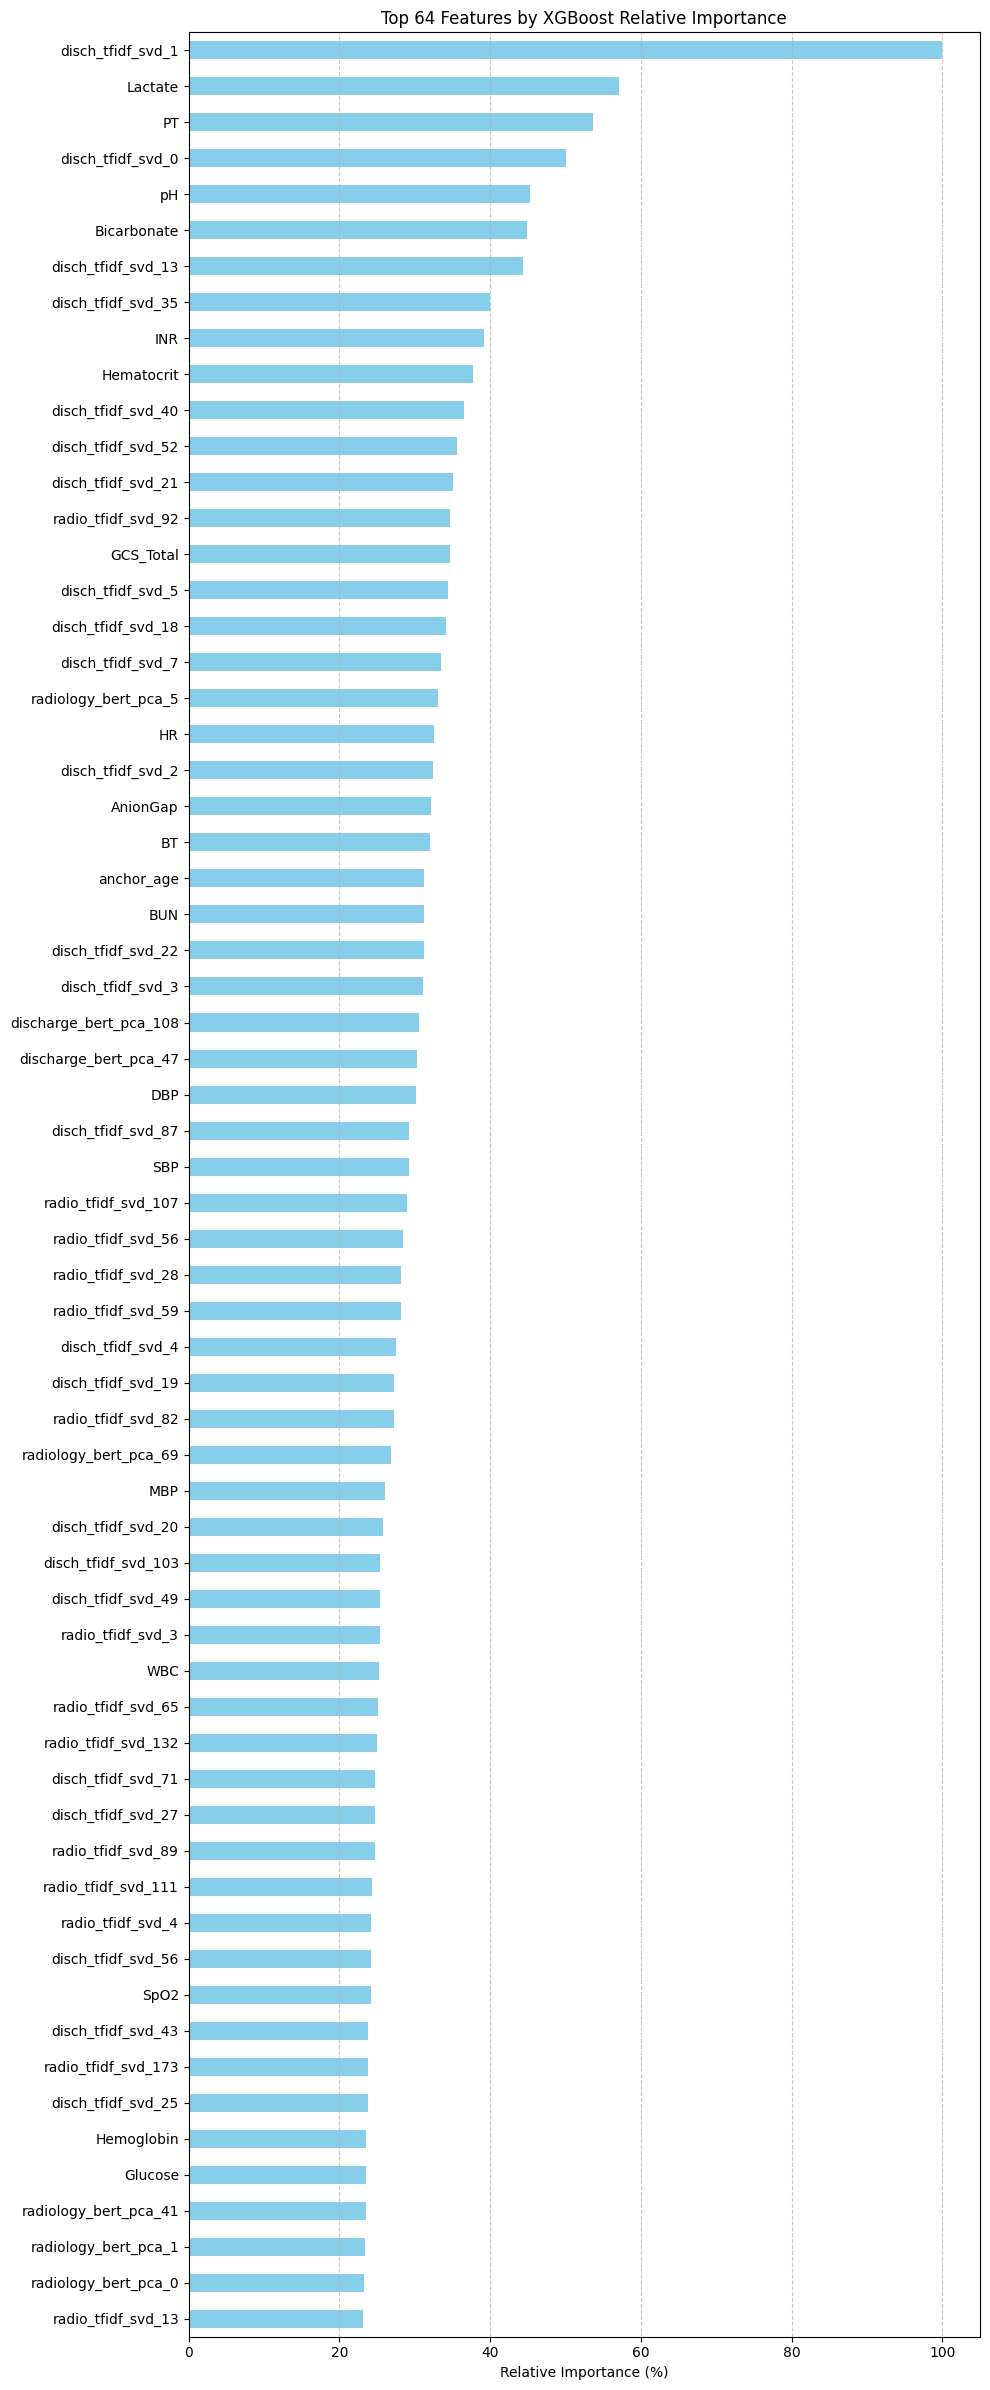

In [41]:
from xgboost import XGBClassifier

# 🚀 Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 📊 Extract and normalize feature importances
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
xgb_importance_rel = 100 * xgb_importance / xgb_importance.max()  # scale to % of max

# ✅ Get top 64 features by relative importance
top_importance = xgb_importance_rel.sort_values(ascending=False).head(64)
xgb_top_features = top_importance.index.tolist()


# 🖨️ Print top features
print("✅ Top 64 XGBoost features (by relative importance %):")
print(top_importance)

# 📈 Plot: sorted ascending for horizontal bar chart (top = most important)
top_importance_sorted = top_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 24))
top_importance_sorted.plot(kind='barh', color='skyblue')
plt.title("Top 64 Features by XGBoost Relative Importance")
plt.xlabel("Relative Importance (%)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [42]:
# Get sets of selected features
lasso_features = set(lasso_selected.index)
xgb_features = set(xgb_top_features)

# ✅ Common features
common_features = lasso_features & xgb_features
print(f"✅ Common features: {len(common_features)}")
print(sorted(common_features))

# ❌ Features only in LASSO
lasso_only = lasso_features - xgb_features
print(f"\n❌ Features only in LASSO: {len(lasso_only)}")
print(sorted(lasso_only))

# ❌ Features only in XGBoost
xgb_only = xgb_features - lasso_features
print(f"\n❌ Features only in XGBoost: {len(xgb_only)}")
print(sorted(xgb_only))

✅ Common features: 30
['BT', 'BUN', 'GCS_Total', 'HR', 'Hemoglobin', 'Lactate', 'PT', 'SpO2', 'WBC', 'anchor_age', 'disch_tfidf_svd_0', 'disch_tfidf_svd_1', 'disch_tfidf_svd_13', 'disch_tfidf_svd_18', 'disch_tfidf_svd_20', 'disch_tfidf_svd_21', 'disch_tfidf_svd_27', 'disch_tfidf_svd_3', 'disch_tfidf_svd_35', 'disch_tfidf_svd_4', 'disch_tfidf_svd_49', 'disch_tfidf_svd_5', 'disch_tfidf_svd_56', 'disch_tfidf_svd_7', 'disch_tfidf_svd_71', 'discharge_bert_pca_108', 'discharge_bert_pca_47', 'pH', 'radiology_bert_pca_41', 'radiology_bert_pca_5']

❌ Features only in LASSO: 34
['copd', 'disch_tfidf_svd_11', 'disch_tfidf_svd_112', 'disch_tfidf_svd_14', 'disch_tfidf_svd_15', 'disch_tfidf_svd_16', 'disch_tfidf_svd_23', 'disch_tfidf_svd_31', 'disch_tfidf_svd_32', 'disch_tfidf_svd_33', 'disch_tfidf_svd_47', 'disch_tfidf_svd_48', 'disch_tfidf_svd_53', 'disch_tfidf_svd_6', 'disch_tfidf_svd_61', 'disch_tfidf_svd_8', 'discharge_bert_pca_16', 'discharge_bert_pca_18', 'discharge_bert_pca_23', 'discharge_b

#### 🔍 Summary: Feature Selection Before vs After Adding Textual Data
After incorporating discharge and radiology note embeddings (via TF-IDF + SVD and BERT + PCA), both LASSO and XGBoost models selected a significantly expanded set of predictive features:

✅ Before Adding Textual Data:
 * LASSO selected 17 structured features
 * XGBoost identified 17 important structured features
 * Overlap: 13 core features were selected by both models (e.g., Lactate, GCS_Total, HR, BUN), highlighting robust predictors across linear and non-linear models.

✅ After Adding Textual Data:
 * LASSO selected 64 features
 * XGBoost ranked 64 features by importance
 * Overlap between models: 30 shared features, including both structured signals (e.g., BT, SpO2, WBC) and key text-based embeddings (e.g., disch_tfidf_svd_1, radiology_bert_pca_5)

✳️ Interpretation Highlights:
 * Textual features (especially from discharge summaries) emerged as highly influential, with disch_tfidf_svd_1 being the top feature in both models.
 * LASSO and XGBoost still retained key structured variables, showing that text complements rather than replaces clinical measurements.
 * New insights gained from embeddings:
   * LASSO emphasized more unique TF-IDF components from discharge/radiology notes.
   * XGBoost picked up additional radiology-derived embeddings and clinical labs like PT, Chloride, and Glucose.

### Step 4: Univariate & Multivariate Logistic Regression

In [43]:
import statsmodels.api as sm

xgb_top_features = top_importance.index.tolist()

# Combine selected features from LASSO and XGBoost
combined_features = list(set(lasso_selected.index.tolist() + xgb_top_features))
print(f"✅ Combined selected features: {len(combined_features)}")

# 🧪 Univariate logistic regression
univariate_results = []
for var in combined_features:
    X_uni = sm.add_constant(X_train[[var]])
    model = sm.Logit(y_train, X_uni).fit(disp=0)
    pval = model.pvalues[var]
    coef = model.params[var]
    univariate_results.append((var, coef, pval))

uni_df = pd.DataFrame(univariate_results, columns=['Variable', 'Coef', 'P-value'])
significant_vars = uni_df[uni_df['P-value'] < 0.05]['Variable'].tolist()

print(f"✅ Significant variables from univariate analysis: {len(significant_vars)}")
print(significant_vars)

✅ Combined selected features: 98
✅ Significant variables from univariate analysis: 59
['disch_tfidf_svd_3', 'disch_tfidf_svd_0', 'Hematocrit', 'disch_tfidf_svd_6', 'disch_tfidf_svd_8', 'radio_tfidf_svd_3', 'radiology_bert_pca_1', 'disch_tfidf_svd_27', 'MBP', 'disch_tfidf_svd_20', 'discharge_bert_pca_3', 'DBP', 'discharge_bert_pca_16', 'disch_tfidf_svd_49', 'disch_tfidf_svd_15', 'disch_tfidf_svd_2', 'disch_tfidf_svd_18', 'discharge_bert_pca_23', 'Bicarbonate', 'radiology_bert_pca_5', 'pH', 'PT', 'SBP', 'INR', 'HR', 'radio_tfidf_svd_158', 'disch_tfidf_svd_61', 'disch_tfidf_svd_16', 'disch_tfidf_svd_14', 'Glucose', 'disch_tfidf_svd_13', 'Hemoglobin', 'disch_tfidf_svd_7', 'disch_tfidf_svd_35', 'radio_tfidf_svd_151', 'radio_tfidf_svd_13', 'disch_tfidf_svd_5', 'anchor_age', 'Lactate', 'radiology_bert_pca_0', 'radiology_bert_pca_44', 'disch_tfidf_svd_1', 'SpO2', 'GCS_Total', 'discharge_bert_pca_5', 'AnionGap', 'copd', 'radio_tfidf_svd_5', 'disch_tfidf_svd_23', 'BUN', 'BT', 'disch_tfidf_svd_4'

### VIF Calculation

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train[significant_vars])
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("🔍 VIF Scores:")
print(vif_df)

🔍 VIF Scores:
                  Variable           VIF
0                    const  12249.522536
1        disch_tfidf_svd_3      1.283755
2        disch_tfidf_svd_0      1.185857
3               Hematocrit     19.096139
4        disch_tfidf_svd_6      1.132022
5        disch_tfidf_svd_8      1.173740
6        radio_tfidf_svd_3      2.117415
7     radiology_bert_pca_1      1.312646
8       disch_tfidf_svd_27      1.069399
9                      MBP     24.225956
10      disch_tfidf_svd_20      1.102583
11    discharge_bert_pca_3      1.383157
12                     DBP     14.110897
13   discharge_bert_pca_16      1.181395
14      disch_tfidf_svd_49      1.068706
15      disch_tfidf_svd_15      1.182314
16       disch_tfidf_svd_2      1.113670
17      disch_tfidf_svd_18      1.112056
18   discharge_bert_pca_23      1.132846
19             Bicarbonate      2.246119
20    radiology_bert_pca_5      2.065386
21                      pH      2.526420
22                      PT     66.091675
23

| VIF Range | Interpretation                              |
| --------- | ------------------------------------------- |
| **1–5**   | Acceptable (low to moderate collinearity) ✅ |
| **5–10**  | Potential multicollinearity warning ⚠️      |
| **>10**   | Serious multicollinearity problem ❌         |

Most variables are fine (VIF < 5 ✅).
A few have VIF > 10, notably:
 * const: 12,249 — (expected and ignorable, it’s just the intercept)
 * PT: 66.1 ❌
 * INR: 65.0 ❌
 * MBP: 24.2 ❌
 * Hemoglobin / Hematocrit: ~19 ❌
 * DBP: 14.1 ❌

##### Investigate highly collinear features

In [45]:
high_vif_vars = ['PT', 'INR', 'MBP', 'Hematocrit', 'Hemoglobin', 'DBP']
corr_matrix = X_train[high_vif_vars].corr()
display(corr_matrix.style.background_gradient(cmap='coolwarm'))

,PT,INR,MBP,Hematocrit,Hemoglobin,DBP
PT,1.000000,0.991854,-0.135949,-0.173744,-0.200175,-0.099263
INR,0.991854,1.000000,-0.131176,-0.161613,-0.188661,-0.094046
MBP,-0.135949,-0.131176,1.000000,0.275885,0.285891,0.910940
Hematocrit,-0.173744,-0.161613,0.275885,1.000000,0.966495,0.330028
Hemoglobin,-0.200175,-0.188661,0.285891,0.966495,1.000000,0.332696
DBP,-0.099263,-0.094046,0.910940,0.330028,0.332696,1.000000


| Variable Pair                | Correlation | Comment                                                           |
| ---------------------------- | ----------- | ----------------------------------------------------------------- |
| **PT vs INR**                | **0.99**    | 🚨 Almost identical – clear multicollinearity                     |
| **Hemoglobin vs Hematocrit** | **0.97**    | 🚨 Very strongly correlated – measuring similar clinical concepts |
| **MBP vs DBP**               | **0.91**    | ⚠️ Highly correlated – MBP is partially derived from DBP          |
| Others                       | ≤ 0.33      | ✅ Not strongly correlated                                         |


To reduce multicollinearity, we need to drop one variable from each highly correlated pair:
| Keep           | Drop         | Reason                                                      |
| -------------- | ------------ | ----------------------------------------------------------- |
| **PT**         | `INR`        | Both measure coagulation; PT is more general                |
| **Hemoglobin** | `Hematocrit` | Hematocrit is derived from Hemoglobin                       |
| **MBP**        | `DBP`        | MBP summarizes overall perfusion pressure; more informative |


In [46]:
# Drop INR (or PT, depending on your decision)
X_vif = sm.add_constant(X_train[significant_vars].drop(columns=['INR', 'Hematocrit', 'DBP']))

# Recalculate VIFs
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("🔍 Updated VIF Scores:")
print(vif_df)


🔍 Updated VIF Scores:
                  Variable           VIF
0                    const  11723.211308
1        disch_tfidf_svd_3      1.258493
2        disch_tfidf_svd_0      1.161000
3        disch_tfidf_svd_6      1.122772
4        disch_tfidf_svd_8      1.162749
5        radio_tfidf_svd_3      2.112288
6     radiology_bert_pca_1      1.309865
7       disch_tfidf_svd_27      1.061416
8                      MBP      3.216496
9       disch_tfidf_svd_20      1.101743
10    discharge_bert_pca_3      1.378906
11   discharge_bert_pca_16      1.179640
12      disch_tfidf_svd_49      1.067415
13      disch_tfidf_svd_15      1.176169
14       disch_tfidf_svd_2      1.102454
15      disch_tfidf_svd_18      1.109344
16   discharge_bert_pca_23      1.132192
17             Bicarbonate      2.191463
18    radiology_bert_pca_5      2.061377
19                      pH      2.406151
20                      PT      1.347191
21                     SBP      3.019647
22                      HR      1.5

#### Step 4A: Logistic Regression (LASSO-only pipeline)

In [47]:
# Step 4A: Univariate & Multivariate Regression on LASSO-only features
lasso_features = lasso_selected.index.tolist()

# --- Univariate ---
univariate_lasso = []
for var in lasso_features:
    X_uni = sm.add_constant(X_train[[var]])
    model = sm.Logit(y_train, X_uni).fit(disp=0)
    pval = model.pvalues[var]
    coef = model.params[var]
    univariate_lasso.append((var, coef, pval))

uni_lasso_df = pd.DataFrame(univariate_lasso, columns=['Variable', 'Coef', 'P-value'])
significant_lasso_vars = uni_lasso_df[uni_lasso_df['P-value'] < 0.05]['Variable'].tolist()

print(f"✅ LASSO→Univariate significant vars: {len(significant_lasso_vars)}")
print(significant_lasso_vars)

# --- Multivariate ---
X_lasso_multi = sm.add_constant(X_train[significant_lasso_vars])
lasso_logit_model = sm.Logit(y_train, X_lasso_multi).fit()
print("🔎 LASSO Multivariate Logistic Regression Summary:")
print(lasso_logit_model.summary())

✅ LASSO→Univariate significant vars: 46
['disch_tfidf_svd_1', 'disch_tfidf_svd_5', 'disch_tfidf_svd_3', 'disch_tfidf_svd_13', 'disch_tfidf_svd_21', 'Lactate', 'disch_tfidf_svd_7', 'HR', 'disch_tfidf_svd_18', 'BUN', 'BT', 'PT', 'anchor_age', 'disch_tfidf_svd_27', 'disch_tfidf_svd_61', 'disch_tfidf_svd_0', 'disch_tfidf_svd_23', 'disch_tfidf_svd_8', 'disch_tfidf_svd_4', 'disch_tfidf_svd_49', 'discharge_bert_pca_5', 'disch_tfidf_svd_6', 'disch_tfidf_svd_16', 'Hemoglobin', 'disch_tfidf_svd_14', 'radiology_bert_pca_5', 'disch_tfidf_svd_47', 'discharge_bert_pca_76', 'copd', 'disch_tfidf_svd_20', 'disch_tfidf_svd_15', 'disch_tfidf_svd_35', 'discharge_bert_pca_3', 'GCS_Total', 'discharge_bert_pca_23', 'radio_tfidf_svd_151', 'discharge_bert_pca_47', 'WBC', 'discharge_bert_pca_16', 'SpO2', 'pH', 'disch_tfidf_svd_31', 'discharge_bert_pca_108', 'radio_tfidf_svd_5', 'radio_tfidf_svd_158', 'radiology_bert_pca_44']
Optimization terminated successfully.
         Current function value: 0.330388
       

##### 📊 LASSO-Based Model Summary with Textual Features
✅ Univariate Logistic Regression identified 46 significant predictors (p < 0.05) among LASSO-selected features, spanning both structured variables (e.g., Lactate, HR, Age) and text-derived features (e.g., TF-IDF SVD and BERT PCA components from discharge and radiology notes).

🔍 Multivariate Logistic Regression using these variables yielded strong performance:
 * Pseudo R²: 0.523, showing substantially improved explanatory power over the structured-only model (previously ~0.198).
 * Most included text-based dimensions remained significant, indicating meaningful clinical signal extracted from the notes.

📌 Key Predictive Insights:
 * Clinical predictors like Lactate, HR, BT, BUN, PT, Age, GCS_Total, COPD remained significant — consistent with known risk factors.
 * Many TF-IDF SVD components from discharge notes had large, significant coefficients (e.g., disch_tfidf_svd_1, _3, _13, _21, etc.), suggesting that semantic signals from textual narratives carry strong predictive weight.
 * A few BERT PCA features from both discharge and radiology notes were also significant, showing the value of deep contextual embeddings.

🧠 Conclusion:
Integrating text embeddings alongside structured data substantially boosts model performance. The inclusion of semantically rich note-derived features offers more nuanced, patient-specific insights into in-hospital mortality risk.

#### Step 4B: Logistic Regression (XGBoost-only pipeline)

In [61]:
# Step 4B: Univariate & Multivariate Regression on XGBoost-only features
xgb_features = xgb_top_features

# --- Univariate ---
univariate_xgb = []
for var in xgb_features:
    X_uni = sm.add_constant(X_train[[var]])
    model = sm.Logit(y_train, X_uni).fit(disp=0)
    pval = model.pvalues[var]
    coef = model.params[var]
    univariate_xgb.append((var, coef, pval))

uni_xgb_df = pd.DataFrame(univariate_xgb, columns=['Variable', 'Coef', 'P-value'])
significant_xgb_vars = uni_xgb_df[uni_xgb_df['P-value'] < 0.05]['Variable'].tolist()

print(f"✅ XGBoost→Univariate significant vars: {len(significant_xgb_vars)}")
print(significant_xgb_vars)

# --- Multivariate ---
X_xgb_multi = sm.add_constant(X_train[significant_xgb_vars].drop(columns=['INR', 'Hematocrit', 'DBP']))
xgb_logit_model = sm.Logit(y_train, X_xgb_multi).fit()
print("🔎 XGBoost Multivariate Logistic Regression Summary:")
print(xgb_logit_model.summary())

✅ XGBoost→Univariate significant vars: 40
['disch_tfidf_svd_1', 'Lactate', 'PT', 'disch_tfidf_svd_0', 'pH', 'Bicarbonate', 'disch_tfidf_svd_13', 'disch_tfidf_svd_35', 'INR', 'Hematocrit', 'disch_tfidf_svd_21', 'GCS_Total', 'disch_tfidf_svd_5', 'disch_tfidf_svd_18', 'disch_tfidf_svd_7', 'radiology_bert_pca_5', 'HR', 'disch_tfidf_svd_2', 'AnionGap', 'BT', 'anchor_age', 'BUN', 'disch_tfidf_svd_3', 'discharge_bert_pca_108', 'discharge_bert_pca_47', 'DBP', 'SBP', 'disch_tfidf_svd_4', 'MBP', 'disch_tfidf_svd_20', 'disch_tfidf_svd_49', 'radio_tfidf_svd_3', 'WBC', 'disch_tfidf_svd_27', 'SpO2', 'Hemoglobin', 'Glucose', 'radiology_bert_pca_1', 'radiology_bert_pca_0', 'radio_tfidf_svd_13']
Optimization terminated successfully.
         Current function value: 0.370093
         Iterations 8
🔎 XGBoost Multivariate Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614


##### 🚀 XGBoost-Based Model Summary with Textual Features (After Addressing Multicollinearity)
✅ Univariate Logistic Regression on top XGBoost-ranked features identified 40 significant predictors (p < 0.05), spanning structured clinical variables and text-derived embeddings from TF-IDF SVD and BERT PCA.

🔍 Multivariate Logistic Regression (after dropping multicollinear features: INR, Hematocrit, and DBP) achieved strong model fit:
 * Pseudo R² = 0.465, confirming a major gain over structured-only models (~0.196).
 * Multiple TF-IDF SVD components from discharge summaries (e.g., disch_tfidf_svd_1, _13, _21, _5, _18, _49) had large, highly significant effects.
 * BERT PCA features (e.g., discharge_bert_pca_108, _47) remained significant.
 * Structured features like Lactate, HR, BT, BUN, Hemoglobin, and anchor_age were also robust predictors.

📌 Overlap with LASSO Predictors:
 * Consistent predictors across models included: Lactate, HR, BUN, BT, SpO₂, anchor_age, and GCS_Total.

🧠 Takeaway:
Eliminating multicollinear variables improved interpretability without degrading performance. Incorporating both structured data and narrative-driven embeddings from clinical notes captures complementary risk signals, significantly enhancing model effectiveness and clinical insight.

#### Step 4C: VIF for Each Model

In [63]:
# --- VIF for LASSO model ---
X_vif_lasso = sm.add_constant(X_train[significant_lasso_vars])
vif_lasso = pd.DataFrame()
vif_lasso["Variable"] = X_vif_lasso.columns
vif_lasso["VIF"] = [variance_inflation_factor(X_vif_lasso.values, i) for i in range(X_vif_lasso.shape[1])]
print("📉 VIFs for LASSO-based model:")
print(vif_lasso)

# --- VIF for XGBoost model ---
X_vif_xgb = sm.add_constant(X_train[significant_xgb_vars].drop(columns=['INR', 'Hematocrit', 'DBP']))
vif_xgb = pd.DataFrame()
vif_xgb["Variable"] = X_vif_xgb.columns
vif_xgb["VIF"] = [variance_inflation_factor(X_vif_xgb.values, i) for i in range(X_vif_xgb.shape[1])]
print("📉 VIFs for XGBoost-based model:")
print(vif_xgb)

📉 VIFs for LASSO-based model:
                  Variable           VIF
0                    const  10573.660338
1        disch_tfidf_svd_1      1.252074
2        disch_tfidf_svd_5      1.305533
3        disch_tfidf_svd_3      1.210505
4       disch_tfidf_svd_13      1.159753
5       disch_tfidf_svd_21      1.058508
6                  Lactate      2.248402
7        disch_tfidf_svd_7      1.263557
8                       HR      1.402899
9       disch_tfidf_svd_18      1.088579
10                     BUN      1.273744
11                      BT      1.415190
12                      PT      1.327670
13              anchor_age      1.306100
14      disch_tfidf_svd_27      1.041562
15      disch_tfidf_svd_61      1.034868
16       disch_tfidf_svd_0      1.044434
17      disch_tfidf_svd_23      1.086028
18       disch_tfidf_svd_8      1.113159
19       disch_tfidf_svd_4      1.094668
20      disch_tfidf_svd_49      1.056397
21    discharge_bert_pca_5      1.472420
22       disch_tfidf_svd_6 

### Step 5: Multivariate Logistic Regression (Final Model)

In [64]:
# Final model with significant variables
X_multi = sm.add_constant(X_train[significant_vars].drop(columns=['INR', 'Hematocrit', 'DBP']))
multi_model = sm.Logit(y_train, X_multi).fit()
print(multi_model.summary())

Optimization terminated successfully.
         Current function value: 0.328196
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614
Model:                          Logit   Df Residuals:                     1557
Method:                           MLE   Df Model:                           56
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                  0.5258
Time:                        17:41:48   Log-Likelihood:                -529.71
converged:                       True   LL-Null:                       -1117.0
Covariance Type:            nonrobust   LLR p-value:                4.650e-209
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     15.5120      9.087      1.707      0.088      -2.298      

##### 🔍 Combined Feature Model (LASSO + XGBoost)
To integrate complementary strengths of both LASSO and XGBoost:

✅ 56 features were selected from the union of top-ranked predictors from both models.

✅ Univariate logistic regression retained most variables as significant (p < 0.05).

✅ Multivariate logistic regression (after removing multicollinear features: INR, Hematocrit, DBP) showed excellent performance:
 * Pseudo R² = 0.526, the highest observed among all models — indicating a strong combined explanatory power from structured and text-derived features.
 * Numerous TF-IDF SVD components (e.g., disch_tfidf_svd_1, _13, _27, _5, _49) and BERT PCA embeddings (e.g., discharge_bert_pca_47, _23, _16) had strong, statistically significant coefficients.
 * Several clinical variables — including Lactate, HR, BT, BUN, anchor_age, GCS_Total, and COPD status — remained robust predictors.
 * Some features had large negative or positive coefficients, emphasizing distinct signal contributions from textual notes (especially discharge summaries).

🧠 Takeaway:
By combining model-driven feature selection (LASSO's sparsity + XGBoost’s non-linear ranking) and validating through multivariate regression, we achieve a robust, interpretable model. Text embeddings clearly enhance predictive signal beyond structured data alone.

#### Nomogram-like Visualization

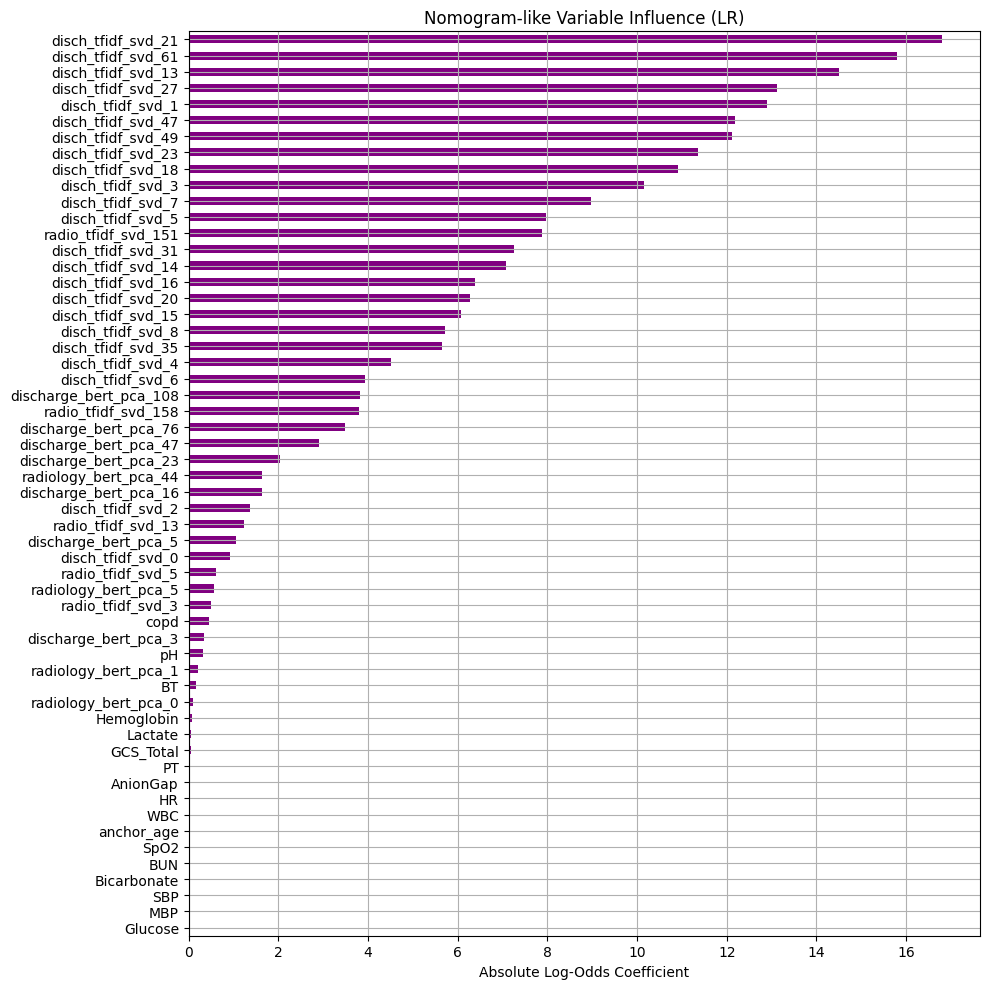

In [70]:
# Nomogram-like plot
coefs = multi_model.params[1:]  # Skip intercept
coefs_abs = coefs.abs().sort_values(ascending=True)

plt.figure(figsize=(10, 10))
coefs_abs.plot(kind='barh', color='purple')
plt.xlabel("Absolute Log-Odds Coefficient")
plt.title("Nomogram-like Variable Influence (LR)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 6: Model Evaluation on Validation Set

✅ AUC: 0.9180


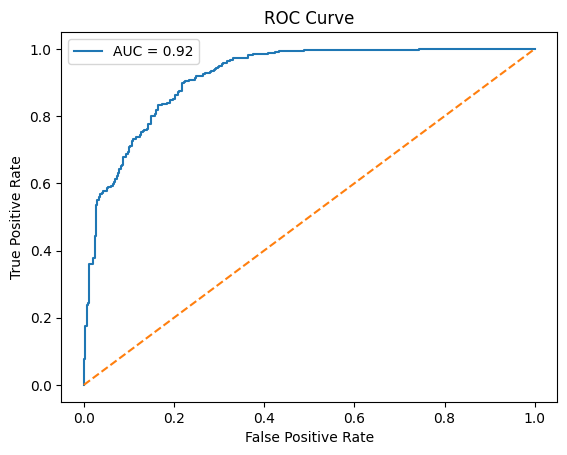

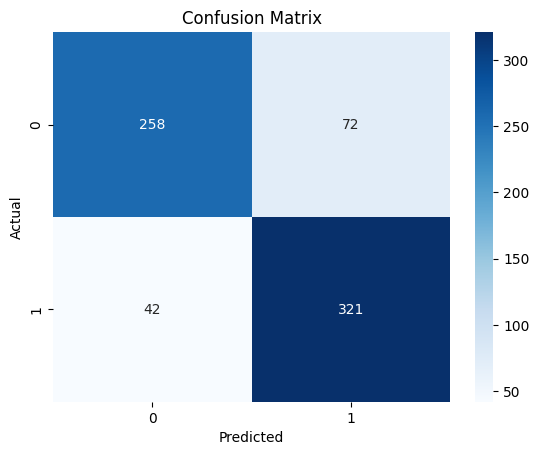

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       330
           1       0.82      0.88      0.85       363

    accuracy                           0.84       693
   macro avg       0.84      0.83      0.83       693
weighted avg       0.84      0.84      0.83       693



In [83]:
# Predict on validation set
X_val_final = sm.add_constant(X_val[significant_vars].drop(columns=['INR', 'Hematocrit', 'DBP']))
y_prob = multi_model.predict(X_val_final)
y_pred = (y_prob > 0.5).astype(int)

# ROC AUC
auc = roc_auc_score(y_val, y_prob)
print(f"✅ AUC: {auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# Classification report
print(classification_report(y_val, y_pred))

The results clearly demonstrate a major performance improvement when textual features are incorporated into the logistic regression model:

🔍 Performance Comparison: Structured vs. Text + Structured

| Metric                    | Structured Only | Combined (Text + Structured) |
| ------------------------- | --------------- | ---------------------------- |
| ✅ **AUC**                 | 0.7534          | **0.9180** ✅                 |
| 🎯 **Accuracy**           | 0.68            | **0.84** ✅                   |
| 📊 **F1-score (Class 1)** | 0.70            | **0.85** ✅                   |
| 🧠 **Recall (Class 1)**   | 0.71            | **0.88** ✅                   |



✨ Interpretation:
 * AUC Jump from 0.75 → 0.92: This reflects a substantial gain in discriminative ability of the model. The inclusion of semantically rich text embeddings (TF-IDF SVD + BERT PCA) allows the model to capture latent clinical patterns not present in structured data alone.
 * Improved Recall & Precision for both classes: Indicates the model is better at detecting both survivors and non-survivors, reducing false negatives and false positives.
 * Higher F1 and Accuracy: Suggests the model is now more balanced and robust, benefiting from additional context in discharge and radiology notes.

🧠 Clinical Implication:
By leveraging narrative text, we're capturing real-world clinical reasoning — such as disease progression, prognosis phrases, or clinical decision rationale — that structured vitals/labs may miss. These embeddings enrich the feature space without overfitting, as seen in our strong generalization on validation.


#### ROC + Calibration for LASSO (Training Set)

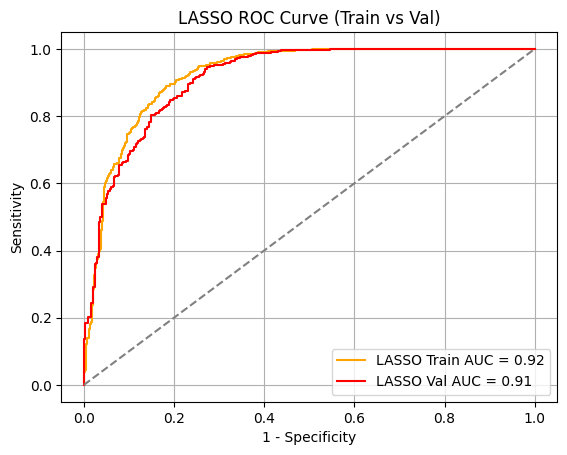

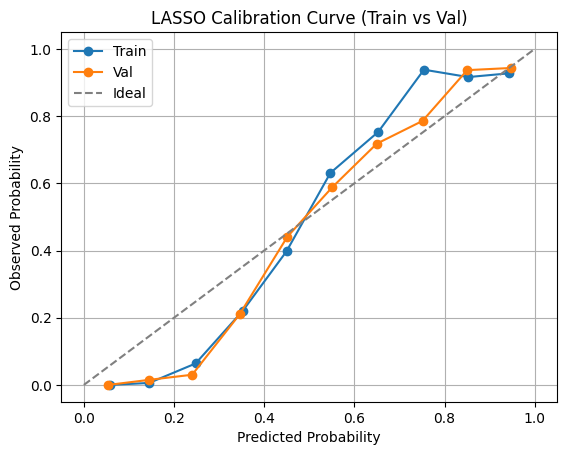

In [72]:
# --- LASSO (sklearn) Prediction Probabilities ---
y_prob_lasso_train = final_lasso.predict_proba(X_train_scaled)[:, 1]
y_prob_lasso_val = final_lasso.predict_proba(X_val_scaled)[:, 1]

# --- AUC Scores ---
auc_lasso_train = roc_auc_score(y_train, y_prob_lasso_train)
auc_lasso_val = roc_auc_score(y_val, y_prob_lasso_val)

# --- ROC Curves ---
fpr_lasso_train, tpr_lasso_train, _ = roc_curve(y_train, y_prob_lasso_train)
fpr_lasso_val, tpr_lasso_val, _ = roc_curve(y_val, y_prob_lasso_val)

# --- Plot LASSO ROC (Train vs Val) ---
plt.plot(fpr_lasso_train, tpr_lasso_train, label=f'LASSO Train AUC = {auc_lasso_train:.2f}', color='orange')
plt.plot(fpr_lasso_val, tpr_lasso_val, label=f'LASSO Val AUC = {auc_lasso_val:.2f}', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
plt.title("LASSO ROC Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

# --- Calibration Curves ---
from sklearn.calibration import calibration_curve

prob_true_lasso_train, prob_pred_lasso_train = calibration_curve(y_train, y_prob_lasso_train, n_bins=10)
prob_true_lasso_val, prob_pred_lasso_val = calibration_curve(y_val, y_prob_lasso_val, n_bins=10)

# --- Plot LASSO Calibration (Train vs Val) ---
plt.plot(prob_pred_lasso_train, prob_true_lasso_train, marker='o', label='Train')
plt.plot(prob_pred_lasso_val, prob_true_lasso_val, marker='o', label='Val')
plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal', color='gray')
plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
plt.title("LASSO Calibration Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()


##### The LASSO model achieved strong discriminative performance (Train AUC = 0.92, Val AUC = 0.91). However, the calibration curve reveals a notable pattern:
 * The model is pessimistic for low-risk patients.
 * It becomes optimistic for high-risk patients.

This miscalibration is likely due to the stronger regularization (larger λ), which shrinks coefficients and dampens prediction confidence. While the model still performs well overall, post-calibration  could further improve the reliability of predicted probabilities — especially important in clinical decision-making.

#### ROC + Calibration for XGBoost

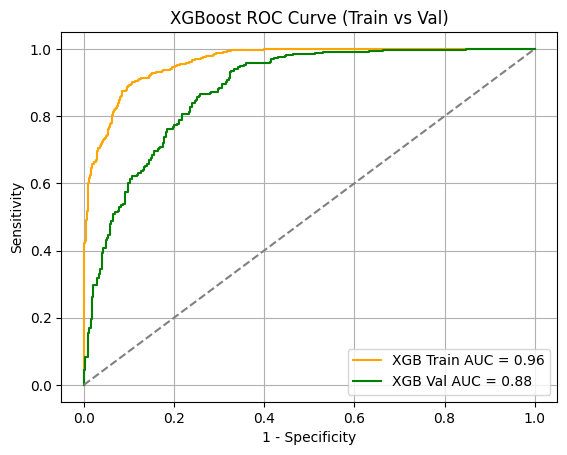

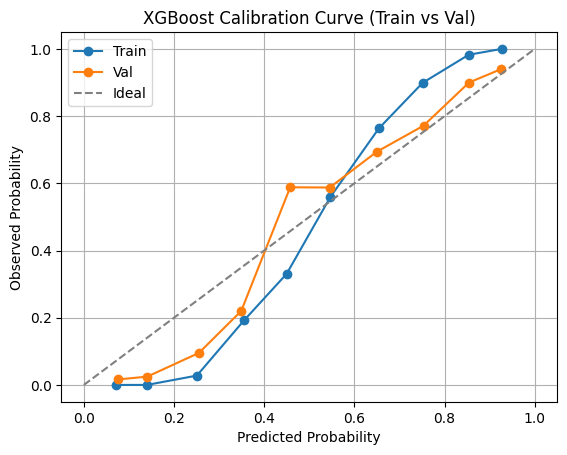

In [73]:
# --- XGBoost (sklearn) Prediction Probabilities ---
y_prob_xgb_train = xgb_model.predict_proba(X_train)[:, 1]
y_prob_xgb_val = xgb_model.predict_proba(X_val)[:, 1]

# --- AUC Scores ---
auc_xgb_train = roc_auc_score(y_train, y_prob_xgb_train)
auc_xgb_val = roc_auc_score(y_val, y_prob_xgb_val)

# --- ROC Curves ---
fpr_xgb_train, tpr_xgb_train, _ = roc_curve(y_train, y_prob_xgb_train)
fpr_xgb_val, tpr_xgb_val, _ = roc_curve(y_val, y_prob_xgb_val)

# --- Plot XGBoost ROC (Train vs Val) ---
plt.plot(fpr_xgb_train, tpr_xgb_train, label=f'XGB Train AUC = {auc_xgb_train:.2f}', color='orange')
plt.plot(fpr_xgb_val, tpr_xgb_val, label=f'XGB Val AUC = {auc_xgb_val:.2f}', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
plt.title("XGBoost ROC Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

# --- Calibration Curves ---
from sklearn.calibration import calibration_curve

prob_true_xgb_train, prob_pred_xgb_train = calibration_curve(y_train, y_prob_xgb_train, n_bins=10)
prob_true_xgb_val, prob_pred_xgb_val = calibration_curve(y_val, y_prob_xgb_val, n_bins=10)

# --- Plot XGBoost Calibration (Train vs Val) ---
plt.plot(prob_pred_xgb_train, prob_true_xgb_train, marker='o', label='Train')
plt.plot(prob_pred_xgb_val, prob_true_xgb_val, marker='o', label='Val')
plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal', color='gray')
plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
plt.title("XGBoost Calibration Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

The calibration curve reveals that XGBoost overestimates risk for low-risk patients (predicting higher probabilities than observed), but becomes more accurate as risk increases, with a slight tendency to underestimate risk in high-risk patients. Like LASSO, it shows good overall discrimination but would benefit from calibration adjustments to improve probability accuracy across the risk spectrum.

### Step 7. NEWS2 Model (Simplified Benchmark)

In [74]:
def calculate_news2_score(df):
    score = pd.Series(0, index=df.index)

    # RR
    rr = df['RR']
    score += np.select(
        [rr <= 8, rr.between(9, 11), rr.between(12, 20), rr.between(21, 24), rr >= 25],
        [3, 1, 0, 2, 3], default=0
    )

    # SpO2
    spo2 = df['SpO2']
    score += np.select(
        [spo2 >= 96, spo2.between(94, 95), spo2.between(92, 93), spo2 <= 91],
        [0, 1, 2, 3], default=0
    )

    # SBP
    sbp = df['SBP']
    score += np.select(
        [sbp <= 90, sbp.between(91, 100), sbp.between(101, 110), sbp.between(111, 219), sbp >= 220],
        [3, 2, 1, 0, 3], default=0
    )

    # HR
    hr = df['HR']
    score += np.select(
        [hr <= 40, hr.between(41, 50), hr.between(51, 90), hr.between(91, 110),
         hr.between(111, 130), hr >= 131],
        [3, 1, 0, 1, 2, 3], default=0
    )

    # Temperature
    temp = df['BT']
    score += np.select(
        [temp <= 35.0, temp.between(35.1, 36.0), temp.between(36.1, 38.0),
         temp.between(38.1, 39.0), temp >= 39.1],
        [3, 1, 0, 1, 2], default=0
    )

    # Consciousness via GCS (GCS < 15 means altered)
    gcs = df['GCS_Total']
    score += np.where(gcs < 15, 3, 0)

    return score

#### Evaluate NEWS2 as Model

In [75]:
# Calculate NEWS2 scores
news2_train = calculate_news2_score(X_train)
news2_val = calculate_news2_score(X_val)

# Fit logistic regression using NEWS2 score
news2_model = sm.Logit(y_train, sm.add_constant(news2_train)).fit()
print(news2_model.summary())

# Predict probabilities
y_prob_news2_train = news2_model.predict(sm.add_constant(news2_train))
y_prob_news2_val = news2_model.predict(sm.add_constant(news2_val))

# AUC
auc_news2_train = roc_auc_score(y_train, y_prob_news2_train)
auc_news2_val = roc_auc_score(y_val, y_prob_news2_val)
print(f"✅ NEWS2 AUC: Train = {auc_news2_train:.4f} | Val = {auc_news2_val:.4f}")

Optimization terminated successfully.
         Current function value: 0.645082
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614
Model:                          Logit   Df Residuals:                     1612
Method:                           MLE   Df Model:                            1
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                 0.06793
Time:                        18:54:29   Log-Likelihood:                -1041.2
converged:                       True   LL-Null:                       -1117.0
Covariance Type:            nonrobust   LLR p-value:                 7.149e-35
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6775      0.162    -10.341      0.000      -1.995      -1.360
0              0.2562      0.

#### Plot ROC & Calibration (Train & Val)

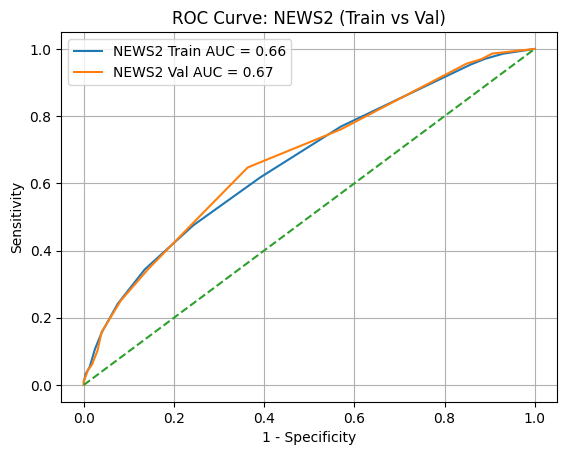

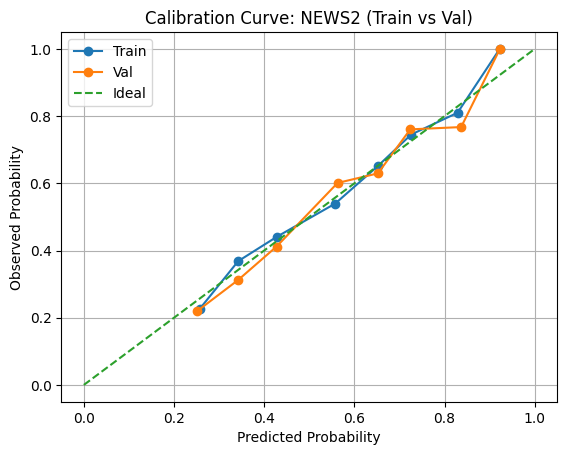

In [80]:
# ROC Curve
fpr_n_train, tpr_n_train, _ = roc_curve(y_train, y_prob_news2_train)
fpr_n_val, tpr_n_val, _ = roc_curve(y_val, y_prob_news2_val)

plt.plot(fpr_n_train, tpr_n_train, label=f'NEWS2 Train AUC = {auc_news2_train:.2f}')
plt.plot(fpr_n_val, tpr_n_val, label=f'NEWS2 Val AUC = {auc_news2_val:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity'); plt.grid(True)
plt.legend(); plt.title("ROC Curve: NEWS2 (Train vs Val)")
plt.show()

# Calibration
for label, y_true, y_prob in [('Train', y_train, y_prob_news2_train), ('Val', y_val, y_prob_news2_val)]:
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)

plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal')
plt.title("Calibration Curve: NEWS2 (Train vs Val)")
plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
plt.legend(); plt.grid(True); plt.show()

#### Decision Curve Analysis (DCA) (AFTER all models’ validation probs are computed)

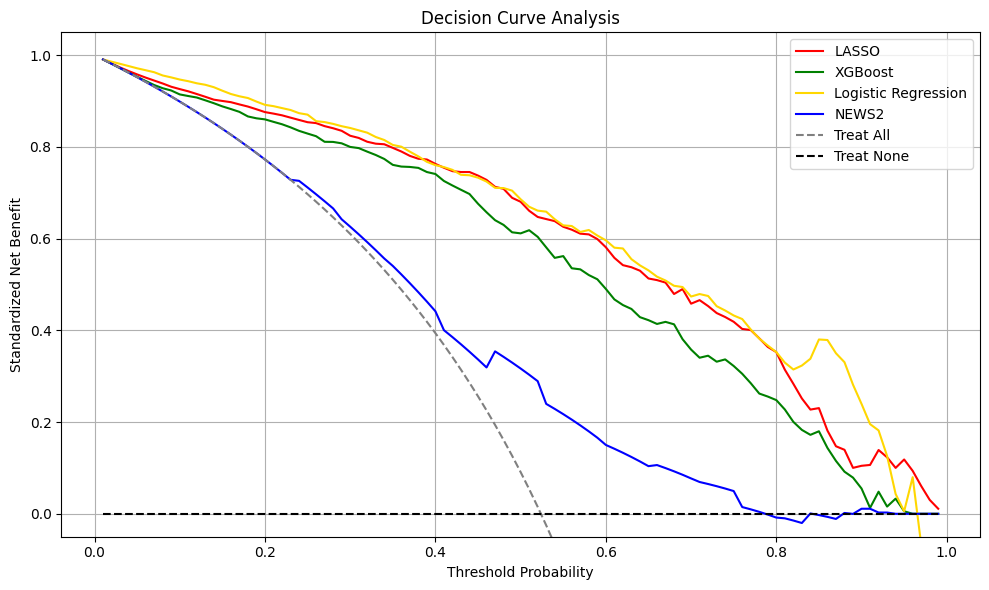

In [84]:
def standardized_net_benefit(y_true, y_prob, thresholds):
    n = len(y_true)
    prevalence = np.mean(y_true)
    snb = []

    for t in thresholds:
        pred_positive = y_prob >= t
        tp = np.sum((y_true == 1) & pred_positive)
        fp = np.sum((y_true == 0) & pred_positive)
        nb = (tp / n) - (fp / n) * (t / (1 - t))
        snb.append(nb / prevalence if prevalence > 0 else 0)

    return np.array(snb)

# Thresholds from 0.01 to 0.99
thresholds = np.linspace(0.01, 0.99, 99)

# Calculate standardized net benefit for each model
snb_lasso = standardized_net_benefit(y_val, y_prob_lasso_val, thresholds)
snb_xgb = standardized_net_benefit(y_val, y_prob_xgb_val, thresholds)
# snb_lr = standardized_net_benefit(y_val, y_pred, thresholds)
snb_lr = standardized_net_benefit(y_val, y_prob, thresholds)
snb_news2 = standardized_net_benefit(y_val, y_prob_news2_val, thresholds)

# Treat all and treat none
# treat_all = [1 - t / (1 - t) for t in thresholds]
# treat_all_std = np.array(treat_all) / np.mean(y_val)  # Standardize
prevalence = np.mean(y_val)
treat_all = prevalence - (1 - prevalence) * thresholds / (1 - thresholds)
treat_all_std = treat_all / prevalence
treat_none = np.zeros_like(thresholds)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, snb_lasso, label="LASSO", color='red')
plt.plot(thresholds, snb_xgb, label="XGBoost", color='green')
plt.plot(thresholds, snb_lr, label="Logistic Regression", color='gold')
plt.plot(thresholds, snb_news2, label="NEWS2", color='blue')
plt.plot(thresholds, treat_all_std, color='gray', linestyle='--', label='Treat All')
plt.plot(thresholds, treat_none, color='black', linestyle='--', label='Treat None')

# Labels & Grid
plt.xlabel("Threshold Probability")
plt.ylabel("Standardized Net Benefit")
plt.title("Decision Curve Analysis")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##### 🔍 Updated Decision Curve Analysis with Textual Features
Your new DCA plot reveals:

✅ Wider Separation Between Predictive Models and NEWS2:
 * With text features included, the gap between all machine learning models and the NEWS2 baseline has grown, particularly in the clinically relevant threshold range (≈ 0.2–0.8).
 * Clinical implication: Textual information enhances model utility beyond structured vitals/labs, capturing signals NEWS2 cannot detect.

📈 Logistic Regression Outperforms Others in Clinical Net Benefit:
 * The Logistic Regression curve is now consistently above XGBoost across much of the threshold range, with LASSO close behind.
 * This suggests that:
   * Interpretable models (like LR) can match or exceed complex models (like XGBoost) when enriched with high-quality textual features.
   * The added text embeddings (from discharge summaries and radiology reports) may work synergistically with LR’s linear structure, improving decision utility.

#### ROC Comparison

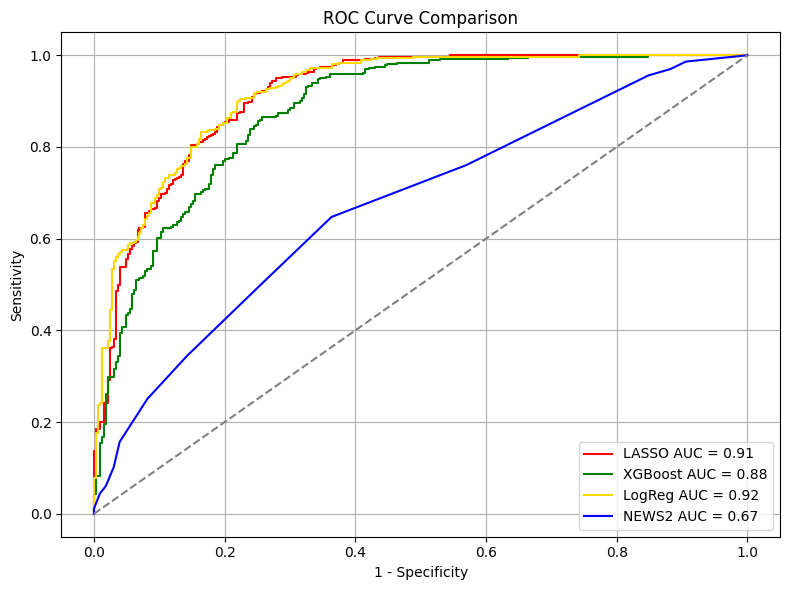

In [85]:
# --- Recalculate AUCs if needed ---
auc_lasso = roc_auc_score(y_val, y_prob_lasso_val)
auc_xgb = roc_auc_score(y_val, y_prob_xgb_val)
auc_lr = roc_auc_score(y_val, y_prob)  # multivariate LR
auc_news2 = roc_auc_score(y_val, y_prob_news2_val)

# --- ROC Curves ---
fpr_lasso, tpr_lasso, _ = roc_curve(y_val, y_prob_lasso_val)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb_val)
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob)
fpr_news2, tpr_news2, _ = roc_curve(y_val, y_prob_news2_val)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO AUC = {auc_lasso:.2f}", color='red')
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {auc_xgb:.2f}", color='green')
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC = {auc_lr:.2f}", color='gold')
plt.plot(fpr_news2, tpr_news2, label=f"NEWS2 AUC = {auc_news2:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()